<a href="https://colab.research.google.com/github/kidd000/Acerbi_Textbook/blob/gh-pages/model2_2_1_GENERATIONS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns

# Exogenous parameters
BEN_CA = 3.6  ##　協力ベネフィット
COST_CA = 0.9  ##　協力コスト
GROUP_SIZE = 8  ## グループサイズ
COST_PUNISHING = 0.2  ## 罰行使コスト
COST_PUNISHED = 0.8  ## 被罰コスト
REVISE_OCCUR = 4  # 更新確率の逆数（毎集合行動後）
ROUND_MAX = 10
RUN_MAX = 20
GENERATION_MAX = 10000
ERROR_RATE = 0.05  ##strategy revision error rate
BIAS_A = 2.0
NORMAL_COST = 0.0
MUTATION = 1/8


def fitness_weight(self, f_sum):
    try:
        return self / f_sum
    except ZeroDivisionError:
        return 0

def payoff_calculate(x_whole, y_whole, x, y, BEN_CA=BEN_CA, COST_CA=COST_CA,
                     COST_PUNISHING=COST_PUNISHING, COST_PUNISHED=COST_PUNISHED):
    return BEN_CA / GROUP_SIZE * (x_whole) - x * COST_CA - (
                1 - x) * COST_PUNISHED * y_whole / GROUP_SIZE - y * COST_PUNISHING * (1 - x_whole / GROUP_SIZE)


##payoffの結果を全ての組み合わせ分作っておく グループサイズにあわせて
keys = []
values = []
for x in range(GROUP_SIZE):
    for y in range(GROUP_SIZE):
        for ix in range(2):
            for iy in range(2):
                identity = (x + ix) * 1000 + (y + iy) * 100 + ix * 10 + iy
                keys.append(identity)
                values.append(payoff_calculate(x + ix, y + iy, ix, iy))

payoff_dict = {}
payoff_dict.update(zip(keys, values))


def payoff_choose(x_whole, y_whole, ix, iy):
    identity = int(x_whole * 1000 + y_whole * 100 + ix * 10 + iy)
    return payoff_dict[identity]


def payoff_max(x_whole, y_whole, ix, iy):
    other_x = x_whole - ix
    other_y = y_whole - iy
    payoff_list = [payoff_choose(other_x, other_y, 0, 0),
                   payoff_choose(other_x + 1, other_y, 1, 0),
                   payoff_choose(other_x + 1, other_y + 1, 1, 1)]
    if payoff_list.index(max(payoff_list)) == 0:
        return [0, 0]
    elif payoff_list.index(max(payoff_list)) == 1:
        return [1, 0]
    elif payoff_list.index(max(payoff_list)) == 2:
        return [1, 1]

"""モデル2-2-1.規範認知罰行使時、命令CP, 記述Cコピー"""
def model2_2_1_generations_moran(GROUP_SIZE=GROUP_SIZE,GENERATION_MAX=GENERATION_MAX, REVISE_OCCUR=REVISE_OCCUR,
                         RUN_MAX=RUN_MAX, ERROR_RATE=ERROR_RATE, BIAS_A=BIAS_A, NORMAL_COST=NORMAL_COST, MUTATION = MUTATION):

    """アウトプット用のデータフレームを作る"""
    output = pd.DataFrame(data={"run" : np.repeat(range(1, RUN_MAX + 1), repeats=GENERATION_MAX, axis=0),
                                       "generations" : np.array(list(range(1, GENERATION_MAX + 1)) * RUN_MAX)})
    output["run"] = np.repeat(range(1, RUN_MAX + 1), repeats=GENERATION_MAX, axis=0)
    output["generation"] = np.array(list(range(1, GENERATION_MAX + 1)) * RUN_MAX)
    # 最後にデータフレームに追加する、世代毎の各戦略を格納するnp2darray
    p_DN_array = np.zeros((RUN_MAX,GENERATION_MAX))
    p_CN_array = np.zeros((RUN_MAX,GENERATION_MAX))
    p_CP_array = np.zeros((RUN_MAX,GENERATION_MAX))
    # 最後にデータフレームに追加する、世代毎のエージェントのタイプを格納するnp2darray
    normal_array = np.zeros((RUN_MAX, GENERATION_MAX))
    descriptive_array = np.zeros((RUN_MAX, GENERATION_MAX))
    injunctive_array = np.zeros((RUN_MAX, GENERATION_MAX))
    # 最後にデータフレームに追加する、世代毎の平均利得を格納するnp2darray
    w_array = np.zeros((RUN_MAX, GENERATION_MAX))

    '''ランのループ開始'''
    for run_num in range(RUN_MAX):

        # 1世代目が始まる前に、個人の戦略（利得計算用）を格納するnp2darrayをセット
        population_x_array = np.zeros((GENERATION_MAX, GROUP_SIZE))
        population_y_array = np.zeros((GENERATION_MAX, GROUP_SIZE))

        # 1世代目が始まる前に、すべてのエージェントをノーマルに割り当てる
        population_type_array = np.repeat(np.array("normal", dtype=object), GROUP_SIZE)

        # 1世代目が始まる前に、ランダムに戦略を割り当てる
        for i in range(GROUP_SIZE):
            population_x_array[0, i] = random.randint(0, 1)  ## 協力するかどうか50%
            if population_x_array[0, i] == 0:  ## 協力しない人は罰は行わないという設定なのでスルー
                continue
            else:  ## 協力する人は50％で罰を行う
                population_y_array[0, i] = random.randint(0, 1)

        '''世代のループ開始'''
        for gen_num in range(GENERATION_MAX):

            # その世代のエージェントタイプの頻度を集計して、np2darrayに格納する
            normal_array[run_num, gen_num] = np.sum(population_type_array == "normal")
            descriptive_array[run_num, gen_num] = np.sum(population_type_array == "descriptive")
            injunctive_array[run_num, gen_num] = np.sum(population_type_array == "injunctive")

            '''公共財ゲームで使う配列のリセット'''
            # 個人の利得（適応度計算用）を格納するnp2darrayのリセット
            population_payoff_array = np.zeros(GROUP_SIZE)

            '''公共財ゲーム'''
            """公共財ゲーム①：行動修正"""
            # 初めの世代だけ行動修正を行わずに、ランダムに割り当てられた行動をとる
            if gen_num > 0:
                for i in range(GROUP_SIZE):

                    """normal typeの行動修正"""
                    # 前のラウンドで何の戦略をとっていたか、ノーマルタイプの行動修正に必要となる情報
                    x = population_x_array[gen_num-1, i]
                    y = population_y_array[gen_num-1, i]

                    x_whole = np.count_nonzero(population_x_array[gen_num-1, :])
                    y_whole = np.count_nonzero(population_y_array[gen_num-1, :])

                    if population_type_array[i] == "normal":
                        # （前のラウンドの自分以外の戦略が維持されると仮定して）このラウンドの効用を最大にする戦略を計算
                        # x,y_wholeに関しては、前のgen_numで割り当てられたものを引き継ぐので、このラウンドでカウントする必要はない
                        x_next, y_next = payoff_max(x_whole, y_whole, x, y)

                        # 4(REVIZE_OCCUR)分の1の確率で戦略修正
                        if random.randint(1, REVISE_OCCUR) == 1:
                            # 95%の確率で利得を最大化する戦略に　5%の確率でランダムに戦略修正（DN-50%,CN-25%,CP-25%,）
                            act_error = random.randint(1, 100)
                            if act_error <= 100 * (1 - ERROR_RATE):
                                population_x_array[gen_num, i] = x_next
                                population_y_array[gen_num, i] = y_next
                            else:
                                population_x_array[gen_num, i] = random.randint(0, 1)
                                if population_x_array[gen_num, i] == 0:
                                    continue
                                else:
                                    population_y_array[gen_num, i] = random.randint(0, 1)
                        # 4分の3の確率で戦略修正しない
                        else:
                            population_x_array[gen_num, i] = x
                            population_y_array[gen_num, i] = y

                    """descriptive typeの行動修正(MODEL_1)"""
                    if population_type_array[i] == "descriptive":
                        # コピー確率を決定―多数派同調タイプ2
                        copy_probability = (((x_whole - x) / GROUP_SIZE) ** BIAS_A) / (
                                (((x_whole - x) / GROUP_SIZE) ** BIAS_A) + ((1 - (x_whole - x) / GROUP_SIZE) ** BIAS_A))
                        if np.random.choice([True, False], p=[copy_probability, 1 - copy_probability], size=1) == True:
                            population_x_array[gen_num, i] = 1

                    """injunctive typeの行動修正(MODEL2)"""
                    if population_type_array[i] == "injunctive":
                        # 前のラウンドで罰行使者がいた場合は、CP戦略　それ以外は、前のラウンドの行動を引き継ぐ（MODEL2_2_1）
                        if y_whole > 0:
                            population_x_array[gen_num, i] = 1
                            population_y_array[gen_num, i] = 1
                        else:
                            population_x_array[gen_num, i] = x
                            population_y_array[gen_num, i] = y


            """公共財ゲーム②：利得計算"""
            # グループ内で何人がそのラウンドで協力・罰戦略をとるのかをカウントしておく
            x_whole = np.count_nonzero(population_x_array[gen_num, :])
            y_whole = np.count_nonzero(population_y_array[gen_num, :])

            for i in range(GROUP_SIZE):
                # 個々人の戦略を変数に入れる（入れなくてもいいけど、わかりやすいので入れるんだドン！！！）
                x = population_x_array[gen_num, i]
                y = population_y_array[gen_num, i]

                """戦略を記録"""
                if [x, y] == [0, 0]:
                    p_DN_array[run_num, gen_num] += 1
                elif [x, y] == [0, 1]:
                    print("Impossible！！")
                elif [x, y] == [1, 0]:
                    p_CN_array[run_num, gen_num] += 1
                elif [x, y] == [1, 1]:
                    p_CP_array[run_num, gen_num] += 1

                # グループ内のメンバー全員の戦略（x_wholeとy_whole）と自分の戦略（xとy）から、利得計算（関数を使っているので、計算はしてない）
                population_payoff_array[i] = payoff_choose(x_whole, y_whole, x, y)


            '''適応度計算'''
            # その世代をそのまま、個々人の適応度として (ベースラインとして全員に＋１)
            # fitness_list = 1 + np.divide(population_payoff_array, np.sum(population_payoff_array),
            #                              out=np.zeros_like(population_payoff_array), where=np.sum(population_payoff_array)!=0)
            fitness_list = 1 + population_payoff_array
            # ノーマルタイプに適応度上のコストをかける
            fitness_list[population_type_array == "normal"] -= NORMAL_COST

            # その世代の平均利得をw_arrayに格納
            w_array[run_num, gen_num] = np.average(population_payoff_array)


            '''淘汰（モラン モデル）'''

            # 個々人の適応度を合計値で割って、リスト化
            fitness_sum = np.sum(fitness_list)
            fitness_weight_list = list(map(fitness_weight, fitness_list, np.repeat(fitness_sum, GROUP_SIZE)))


            """
            モランモデルタイプ①
            －ラウンド毎に必ず1人分のBirth-Death過程（他のとこで実装されるのはこの形）
            """
            # 複製される人を、適応度に応じて1人決定
            birth_index = np.random.choice(range(GROUP_SIZE), p=fitness_weight_list, size=1)
            # 死ぬ人は、ランダムに決定（=複製される人が死ぬかも）
            death_index = np.random.randint(0,GROUP_SIZE)

            # 死ぬ人と複製される人を入れ替え
            population_type_array[death_index] = population_type_array[birth_index]

            # 複製されるエージェントに、初めの戦略をランダムに割り当てる
            population_x_array[gen_num, death_index] = random.randint(0, 1)  ## 協力するかどうか50%
            if population_x_array[gen_num, death_index] == 0:  ## 協力しない人は罰は行わないという設定なのでスルー
                population_y_array[gen_num, death_index] = 0
            else:  ## 協力する人は50％で罰を行う
                population_y_array[gen_num, death_index] = random.randint(0, 1)

            """
            モランモデルタイプ②
            －それぞれのエージェントに複製されるかどうかdiceを振り、ラウンド毎に期待値0.8人が複製される
            （ライト・フィッシャーモデルの複製（死亡）率-10ラウンドに8人(GROUPSIZE)-と整合性を保つことができるけど、コードが長くなる）            
            """
            # # 複製される人を決定
            # MODIFICATION_RATE = GROUP_SIZE/10
            # ## 個々のエージェントが複製されるかどうかのリスト（True or False）
            # birth_list = np.repeat(False, GROUP_SIZE)
            # birth_rate_list = fitness_weight_list * MODIFICATION_RATE
            # for i in range(GROUP_SIZE):
            #     birth_list[i] = np.random.choice([True, False], p=[birth_rate_list[i], 1-birth_rate_list[i]], size=1)
            #
            # #死ぬ人を決定し、入れ替え
            # ## 1人以上複製される人がいたら
            # if np.sum(birth_list) > 0:
            #     # 複製される人数分、死ぬ人をランダムに決める
            #     death_index = np.random.choice(range(GROUP_SIZE), size=np.sum(birth_list), replace=False)
            #     population_type_array[death_index] = population_type_array[birth_list]


            '''突然変異'''
            # Mutantを突然変異率MUTATIONに従って、決定
            mutations = np.random.choice([True, False], size=GROUP_SIZE, p=[MUTATION, 1 - MUTATION], replace=True)

            # Mutantが1人以上いたら
            if np.sum(mutations) > 0:
                # Mutantのindexを取得
                index_list = [i for i, x in enumerate(mutations) if x == True]
                # イノベーターの形質を新しい形質（今とは違うタイプ）に置き換える
                for index in index_list:
                    if population_type_array[index] == "normal":
                        population_type_array[index] = np.random.choice(a=["descriptive", "injunctive"], size=1)
                    elif population_type_array[index] == "descriptive":
                        population_type_array[index] = np.random.choice(a=["normal", "injunctive"], size=1)
                    elif population_type_array[index] == "injunctive":
                        population_type_array[index] = np.random.choice(a=["normal", "descriptive"], size=1)


                    # Mutantに行動をランダムに割り当てる
                    population_x_array[gen_num, index] = random.randint(0, 1)  ## 協力するかどうか50%
                    if population_x_array[gen_num, index] == 0:  ## 協力しない人は罰は行わないという設定なのでスルー
                        population_y_array[gen_num, index] = 0
                    else:  ## 協力する人は50％で罰を行う
                        population_y_array[gen_num, index] = random.randint(0, 1)


    """output用のデータフレームにnp2darray[run_num, gen_num]を移行（列を追加）"""
    # 全部のランが終わったので、世代毎（世代最後）の各戦略を格納した配列、世代毎のエージェントのタイプを格納した配列、世代毎の利得の平均を格納した配列を追加
    output = output.assign(p_DN = p_DN_array.flatten(),
                           p_CN = p_CN_array.flatten(),
                           p_CP = p_CP_array.flatten(),
                           normal = normal_array.flatten(),
                           descriptive = descriptive_array.flatten(),
                           injunctive = injunctive_array.flatten(),
                           W = w_array.flatten())
    return output

In [ ]:
'''全ランのDN戦略の頻度をプロットする関数'''
def plot_multiple_runs_p_DN(data_model):
    # 世代数取得
    t_max = data_model["generation"].max()

    # 体裁いじいじ
    sns.set_palette("hls",n_colors=24)
    sns.set('poster', 'whitegrid', 'dark', font_scale=1,
            rc={"lines.linewidth": 1, 'grid.linestyle': '--'})
    
    # ランごとの平均値推移
    fig, ax = plt.subplots(figsize=(12, 8))
    sns.lineplot(x="generation", y="p_DN", hue="run", data=data_model, legend = "full", palette="hls")

    # 全ランの平均値推移
    data_model = data_model.set_index(["generation"])
    p_mean_list = data_model["p_DN"].mean(level="generation")

    plt.plot(p_mean_list,marker="None",linestyle="-",linewidth=3.0,color="black")
    plt.legend(bbox_to_anchor=(1.01, 1),borderaxespad=0, title="run")
    plt.ylim(-0.1, 8.1)
    plt.xlabel("Generation")
    plt.ylabel("DN strategy")
    plt.show()

'''戦略の頻度（全ランの平均）をプロットする関数'''
def plot_multiple_runs_strategy(data_model):
    # 世代数取得
    t_max = data_model["generation"].max()

    # 体裁いじいじ
    sns.set_palette("hls",n_colors=24)
    sns.set('poster', 'whitegrid', 'dark', font_scale=1,
            rc={"lines.linewidth": 1, 'grid.linestyle': '--'})
    fig, ax = plt.subplots(figsize=(12, 8))

    # p_SL全ランの平均値推移
    data_model = data_model.set_index(["generation"])
    p_DN_mean_list = data_model["p_DN"].mean(level="generation")
    # p_IL全ランの平均値推移
    p_CN_mean_list = data_model["p_CN"].mean(level="generation")
    # p_CL全ランの平均値推移
    p_CP_mean_list = data_model["p_CP"].mean(level="generation")

    w_list =  data_model["W"].mean(level="generation")

    list_mean = [p_DN_mean_list, p_CN_mean_list, p_CP_mean_list, w_list]
    list_color = ["blue", "green", "red", "black"] 

    ax.plot(list_mean[0], color=list_color[0])
    ax.plot(list_mean[1], color=list_color[1])
    ax.plot(list_mean[2], color=list_color[2])
    ax.plot(list_mean[3], color=list_color[3])

    plt.ylim(-0.1, 8.1)
    plt.xlabel("Generation")
    plt.ylabel("strategy")
    plt.legend(["DN","CN","CP", "W"])
    plt.show()

'''エージェントタイプの頻度（全ランの平均）をプロットする関数'''
def plot_multiple_runs_type(data_model):
    # 世代数取得
    t_max = data_model["generation"].max()

    # 体裁いじいじ
    sns.set_palette("hls",n_colors=24)
    sns.set('poster', 'whitegrid', 'dark', font_scale=1,
            rc={"lines.linewidth": 1, 'grid.linestyle': '--'})
    fig, ax = plt.subplots(figsize=(12, 8))

    # p_SL全ランの平均値推移
    data_model = data_model.set_index(["generation"])
    normal_mean_list = data_model["normal"].mean(level="generation")
    # p_IL全ランの平均値推移
    descriptive_mean_list = data_model["descriptive"].mean(level="generation")
    # p_CL全ランの平均値推移
    injunctive_mean_list = data_model["injunctive"].mean(level="generation")

    w_list =  data_model["W"].mean(level="generation")

    list_mean = [normal_mean_list, descriptive_mean_list, injunctive_mean_list, w_list]
    list_color = ["blue", "green", "red", "black"] 

    ax.plot(list_mean[0], color=list_color[0])
    ax.plot(list_mean[1], color=list_color[1])
    ax.plot(list_mean[2], color=list_color[2])
    ax.plot(list_mean[3], color=list_color[3])

    plt.ylim(-0.1, 8.1)
    plt.xlabel("Generation")
    plt.ylabel("type")
    plt.legend(["normal","descriptive","injunctive", "W"])
    plt.show()

In [ ]:
import time
start = time.time()
data6 = model2_2_1_generations_moran()
end = time.time()
print(end - start)

144.71818351745605


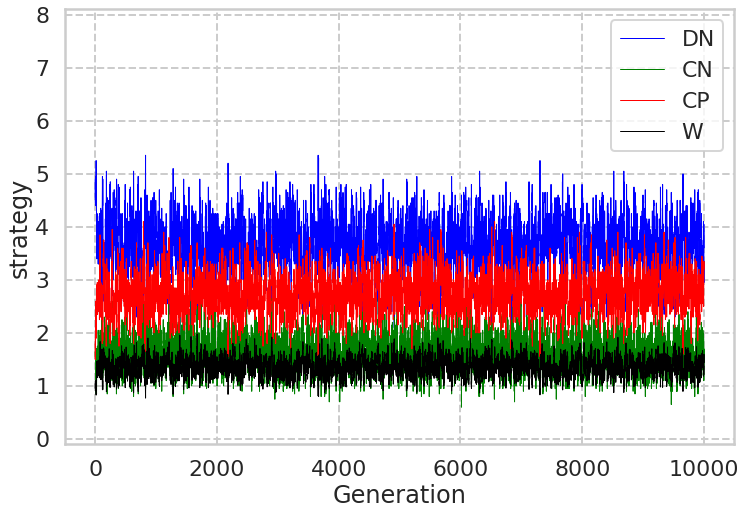

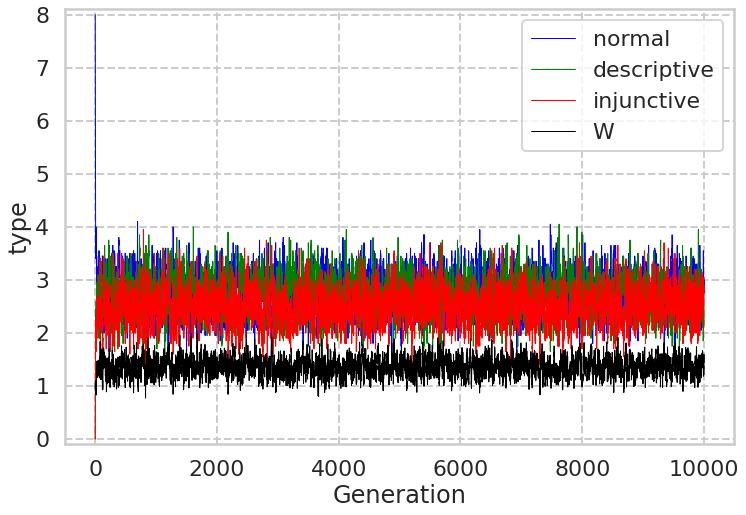

In [ ]:
plot_multiple_runs_strategy(data6)
plot_multiple_runs_type(data6)

In [ ]:
import time
start = time.time()
data7 = model2_2_1_generations_moran(MUTATION=1/80)
end = time.time()
print(end - start)

688.7989313602448


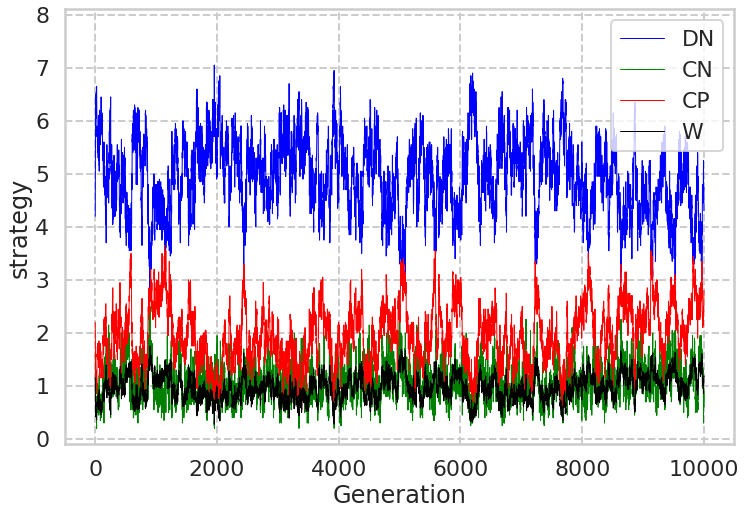

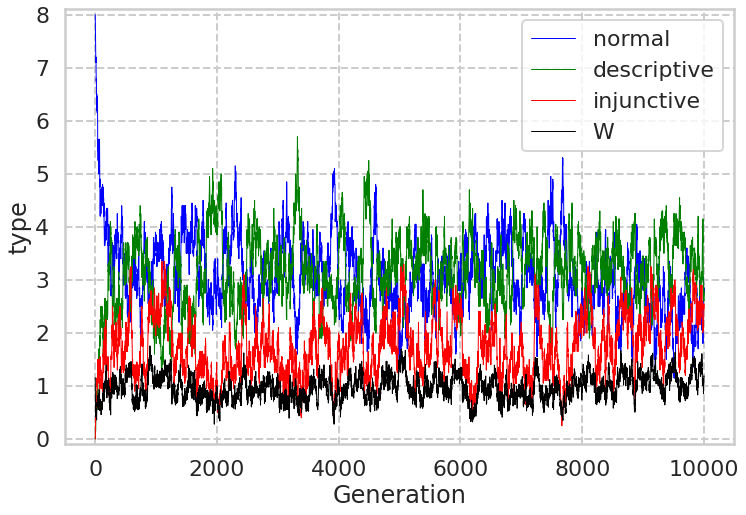

In [ ]:
plot_multiple_runs_strategy(data7)
plot_multiple_runs_type(data7)

In [ ]:
import time
start = time.time()
data8 = model2_2_1_generations_moran(MUTATION=1/80, NORMAL_COST=0.3)
end = time.time()
print(end - start)

528.0719921588898


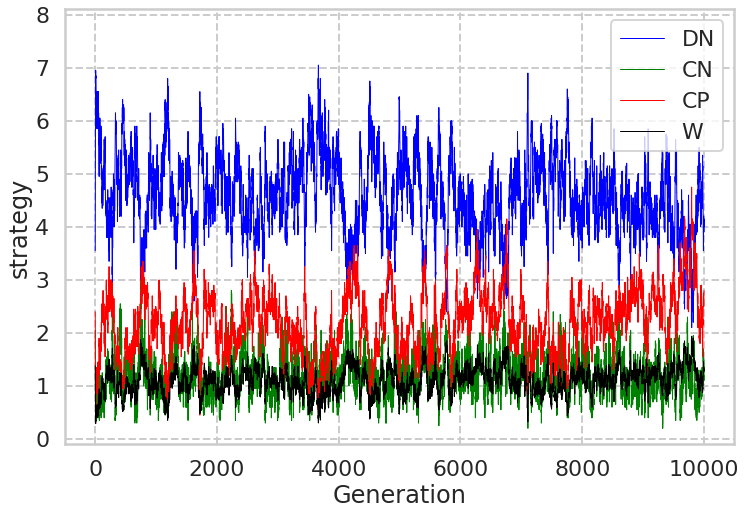

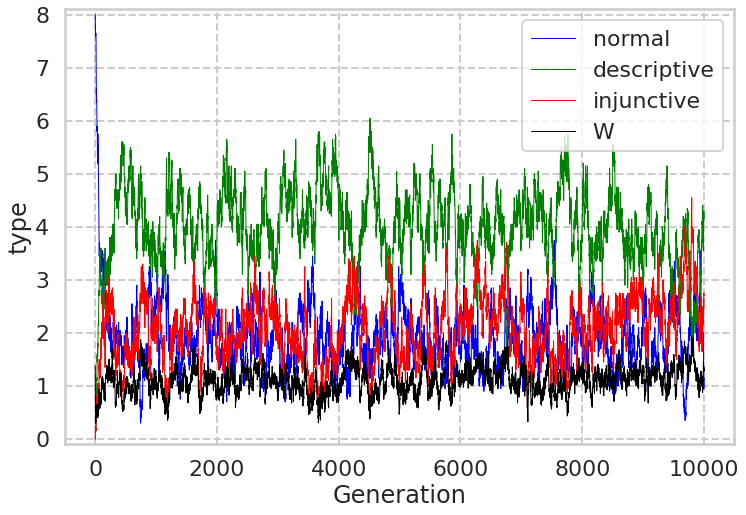

In [ ]:
plot_multiple_runs_strategy(data8)
plot_multiple_runs_type(data8)